In [1]:
import os
#!pip install numpy
import numpy as np
#!pip install  pandas scikit-learn matplotlib joblib tensorflow

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks, optimizers, losses, metrics
import tensorflow as tf

# 🧠 Como o modelo prevê mudanças de comportamento com base na atividade neural

Neste notebook, vamos entender em detalhes **como o Transformer aprende a prever o comportamento futuro**
a partir das janelas de atividade neural.

A ideia central é que cada janela de neurônios representa **um histórico temporal** (o que acabou de acontecer),
e o modelo tenta prever **o comportamento no próximo instante**.

---


## 🧩 1. Estrutura dos dados

Suponha que temos a atividade neural registrada ao longo do tempo:

| Tempo (s) | Neurônio 1 | Neurônio 2 | Neurônio 3 | Comportamento |
|------------|-------------|-------------|-------------|----------------|
| t₀ | 0.12 | 0.05 | 0.01 | grooming |
| t₁ | 0.15 | 0.08 | 0.03 | grooming |
| t₂ | 0.21 | 0.09 | 0.05 | grooming |
| t₃ | 0.32 | 0.15 | 0.10 | rearing |
| t₄ | 0.41 | 0.22 | 0.16 | rearing |
| t₅ | 0.36 | 0.28 | 0.22 | walking |

Se o tamanho da janela for **3**, o modelo cria pares do tipo:

| Janela de entrada (X) | Saída esperada (y) |
|------------------------|--------------------|
| atividade neural em [t₀, t₁, t₂] | comportamento em t₃ |
| atividade neural em [t₁, t₂, t₃] | comportamento em t₄ |
| atividade neural em [t₂, t₃, t₄] | comportamento em t₅ |

---


## 🧠 2. O que o modelo aprende

O Transformer aprende a mapear:
$$
\[
f: [x_{t_0}, x_{t_1}, \dots, x_{t_{n-1}}] \to y_{t_n}
\]
$$
Ou seja, ele usa a sequência de atividade neural (X) para **prever o comportamento futuro (y)**.

Matematicamente, o modelo está sempre tentando antecipar o **estado comportamental no próximo instante**,
com base no histórico de atividade neural imediatamente anterior.

---
## 🔍 3. Interpretação comportamental

Isso significa que o modelo **aprende a reconhecer padrões neurais que precedem uma mudança de comportamento**.

| Situação | Interpretação |
|-----------|----------------|
| Atividade neural estável e repetitiva | O comportamento tende a continuar |
| Atividade neural começa a mudar (novos neurônios ativam) | Uma transição comportamental é iminente |

Por exemplo:

- Se o comportamento atual é “rearing” e o próximo é “walking”,
  o modelo percebe que um certo padrão neural (crescimento de atividade em alguns neurônios motores)
  **antecede essa mudança**.
---


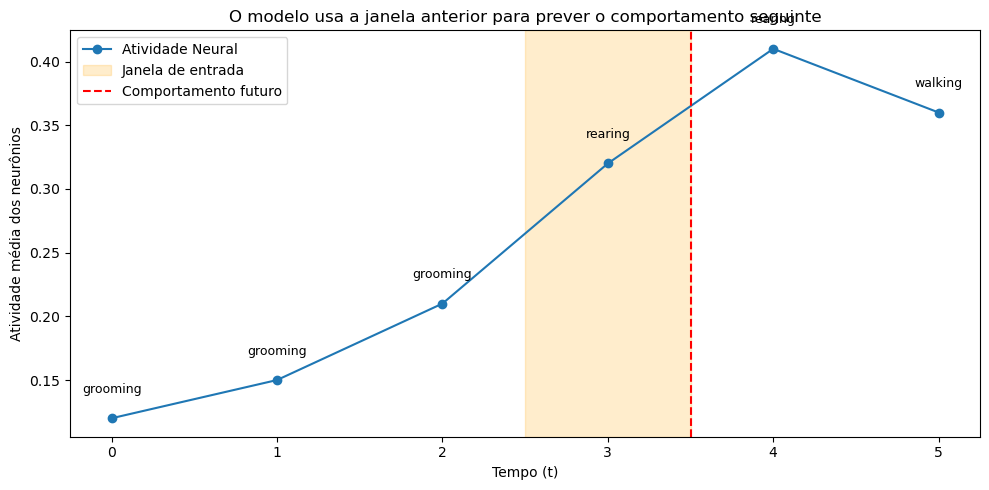

In [2]:
# 📊 5. Exemplo ilustrativo

import numpy as np
import matplotlib.pyplot as plt

# Atividade neural (simplificada)
time = np.arange(6)
activity = np.array([0.12, 0.15, 0.21, 0.32, 0.41, 0.36])
behaviors = ["grooming", "grooming", "grooming", "rearing", "rearing", "walking"]

plt.figure(figsize=(10,5))
plt.plot(time, activity, 'o-', label='Atividade Neural')
for i, b in enumerate(behaviors):
    plt.text(time[i], activity[i]+0.02, b, fontsize=9, ha='center')

plt.axvspan(2.5, 3.5, color='orange', alpha=0.2, label='Janela de entrada')
plt.axvline(3.5, color='red', linestyle='--', label='Comportamento futuro')
plt.title("O modelo usa a janela anterior para prever o comportamento seguinte")
plt.xlabel("Tempo (t)")
plt.ylabel("Atividade média dos neurônios")
plt.legend()
plt.tight_layout()
plt.show()


🔹 A faixa laranja representa a **janela de atividade neural usada como entrada**.  
🔹 A linha vermelha indica o **momento do comportamento que o modelo tenta prever**.

Assim, o Transformer aprende que **mudanças específicas na dinâmica neural**
antecedem **mudanças de comportamento** — tornando-o capaz de antecipar transições.

---
## ✅ Conclusão

- Cada janela temporal contém **a história recente da atividade neural**.  
- O Transformer usa essa sequência para prever **o comportamento no próximo instante**.  
- Isso equivale a **detectar mudanças iminentes de comportamento**, porque ele aprende a reconhecer
  **padrões neurais precursores**.  
- Em termos biológicos, o modelo está identificando **a dinâmica neural que leva à transição comportamental**.

---


In [3]:
lista1 = [
"S2C29-3CH1_neuronal_behaviorDS.xlsx - S2C293CH1_neuronal_behaviorDS.csv"]#,
"""
"S2C29-3CH2_neuronal_behaviorDS.xlsx - S2C293CH2_neuronal_behaviorDS.csv",
"S1C29-SIT1_neuronal_behaviorDS.csv",
"S1C29-SIT2_neuronal_behaviorDS.csv",
"S2C29-SIT3_neuronal_behaviorDS.csv"
]
"""
lista2 = ["S2C29-3CH1"]#, "S2C29-3CH2", "S2C29-SIT1", "S2C29-SIT2", "S2C29-SIT3"]
dd ="S2C29-3CH3_neuronal_behaviorDS.xlsx - S2C293CH3_neuronal_behaviorDS.csv"
dd1 = "S2C29-3CH3"

print('RATO_',str(dd1))
df = pd.read_csv(dd)
# === 1. Carregamento do CSV ===
# Lê o arquivo CSV com os dados de comportamento e atividade neural
#df = pd.read_csv("S2C29-3CH1_neuronal_behaviorDS.xlsx - S2C293CH1_neuronal_behaviorDS.csv")

# Substitui vírgulas por pontos em todos os campos (caso os dados venham no formato europeu de decimal)
df_ = df.replace({',': '.'}, regex=True)

# Mantém os dados com vírgula convertida em ponto para análise posterior
DF = df_

# === 2. Remoção de comportamentos irrelevantes ou artefatos ===
# Remove linhas cujo comportamento é 'vide' (pode indicar ausência de dado relevante)
df_remove = DF.loc[(DF['Behaviour'] == 'vide')]
DF_ = DF.drop(df_remove.index)

# Remove linhas cujo comportamento é 'Main_experimentateur' (possivelmente movimento do experimentador)
df_remove = DF_.loc[(DF_['Behaviour'] == 'Main_experimentateur')]
DF_ = DF_.drop(df_remove.index)

# Remove linhas cujo comportamento é 'on_the_cup' (possivelmente movimento do experimentador)
df_remove = DF_.loc[(DF_['Behaviour'] == 'on_the_cup')]
DF_ = DF_.drop(df_remove.index)

# Remove linhas cujo comportamento é 'on_the_cup' (possivelmente movimento do experimentador)
df_remove = DF_.loc[(DF_['Behaviour'] == 'souris_in_cup')]
DF_ = DF_.drop(df_remove.index)
df_remove = DF_.loc[(DF_['Behaviour'] == 'head')]
DF_ = DF_.drop(df_remove.index)
print('Comportamentos',DF_["Behaviour"].unique())


# === 3. Codificação do comportamento ===

# Extrai os rótulos de comportamento como vetor
y = DF_['Behaviour'].values

# Transforma os comportamentos em rótulos numéricos (ex: 'rearing' → 0, 'walking' → 1, etc.)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Adiciona a coluna com os rótulos numéricos ao DataFrame
DF_['label'] = y

# === 4. Separação dos dados X e y ===

# Remove as colunas 'Behaviour' e 'label' para obter apenas os dados dos neurônios
X = DF_.drop(columns=['Behaviour', 'label'])

# Define y como os rótulos numéricos
y = DF_['label']

# Converte X para array numpy
X = X.values

# === 5. Conversão para float e limpeza dos dados ===

# Inicializa um array vazio com o mesmo formato que X
x = np.zeros([X.shape[0], X.shape[1]])

# Itera sobre todas as células de X
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Se a célula contiver 'le' ou 'pot' (strings não numéricas), substitui por 0
        if X[i, j] == 'le' or X[i, j] == 'pot' or X[i, j] == 'movement' :
            X[i, j] = 0
        # Caso contrário, converte para float
        s = X[i, j]
        f = float(s)
        x[i, j] = f

print(x.shape)  # Mostra o formato do array de dados X convertido para float

# === 6. Reformata a variável de saída y ===

y = y.values
y = y.reshape(-1, 1)

# === 7. Combina y com os dados de entrada X ===

# Concatena os rótulos y com os dados x
ddf = np.concatenate([y, x], axis=1)

# Converte para DataFrame pandas
ddf = pd.DataFrame(ddf)

# Renomeia a primeira coluna para 'Behaviour' (os rótulos numéricos)
ddf.rename(columns={0: 'Behaviour'}, inplace=True)
ddf.head()

RATO_ S2C29-3CH3
Comportamentos ['rearing' 'locomotion' 'contact_pot_not_to_be_social'
 'contact_pot_to_be_social' 'contact_pot_non_social' 'contact_pot_social'
 'grooming']
(4283, 184)


,Behaviour,1,2,3,4,5,6,7,8,9,...,175,176,177,178,179,180,181,182,183,184
0,6.0,0.042307,0.000965,0.004652,0.005998,0.009595,0.002316,0.012907,0.015545,0.005494,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6.0,0.041168,0.000961,0.004517,0.006315,0.009355,0.002294,0.012215,0.014838,0.007073,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6.0,0.039970,0.000937,0.004386,0.006706,0.009131,0.002167,0.011569,0.014168,0.007153,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6.0,0.038766,0.000901,0.004259,0.006677,0.009921,0.002027,0.010967,0.013534,0.006758,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6.0,0.037579,0.001083,0.004137,0.006447,0.009925,0.002643,0.010405,0.012934,0.006239,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
WINDOW_SIZE = 50
STRIDE = 1
BATCH_SIZE = 64
EPOCHS = 80
RANDOM_SEED = 42
MODEL_DIR = "/home/ati/Documentos/Tiago_Ratos/transformer_artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)


In [5]:
print("Dimensão do CSV:", ddf.shape)
print("Colunas:", ddf.columns.tolist())
print("Tipos:\n", ddf.dtypes)

Dimensão do CSV: (4283, 185)
Colunas: ['Behaviour', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184]
Tipos:
 Behaviour    float64
1            float64
2            float64
3            float64
4            float64
              ...   
18

In [6]:
# Detecta coluna de rótulo automaticamente
# --------------------
candidate_labels = []
for col in df.columns:
    nunique = df[col].nunique(dropna=True)
    dtype = df[col].dtype
    if dtype == 'object':
        candidate_labels.append(col)
    elif nunique <= 50 and nunique < df.shape[0]//2 and not np.issubdtype(dtype, np.floating):
        candidate_labels.append(col)
    elif nunique <= 50 and nunique < df.shape[0]//2 and np.issubdtype(dtype, np.integer):
        candidate_labels.append(col)

label_col = candidate_labels[0] if candidate_labels else None
if label_col is None:
    # fallback: última coluna
    label_col = df.columns[-1]
    print("Aviso: não detectei coluna clara de rótulo. Usando última coluna:", label_col)
else:
    print("Coluna detectada como rótulo:", label_col)

Coluna detectada como rótulo: Behaviour


In [7]:
# --------------------
# Escolhe features numéricas
# --------------------
numeric_cols = ddf.select_dtypes(include=[np.number]).columns.tolist()
if label_col in numeric_cols:
    numeric_cols = [c for c in numeric_cols if c != label_col]

# tenta converter object->num se nenhuma numerica encontrada
if len(numeric_cols) == 0:
    for col in df.columns:
        try:
            ddf[col] = pd.to_numeric(ddf[col], errors='raise')
            numeric_cols.append(col)
        except:
            pass

print("Colunas usadas como features (exemplo até 15):", numeric_cols[:15])
if len(numeric_cols) == 0:
    raise RuntimeError("Nenhuma coluna numérica encontrada para usar como features. Verifique o CSV.")


Colunas usadas como features (exemplo até 15): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [8]:
# --------------------
# Preprocessamento
# --------------------
ddf[numeric_cols] = ddf[numeric_cols].interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill')

labels_raw = ddf[label_col].astype(str).values
le = LabelEncoder()
labels_enc = le.fit_transform(labels_raw)
num_classes = len(le.classes_)
print("Número de classes:", num_classes, "Classes:", list(le.classes_))

Número de classes: 7 Classes: ['0.0', '1.0', '2.0', '3.0', '4.0', '5.0', '6.0']


C:\Users\sidne\AppData\Local\Temp\ipykernel_17580\1706994984.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ddf[numeric_cols] = ddf[numeric_cols].interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill')


In [9]:
scaler = StandardScaler()
X_all = scaler.fit_transform(ddf[numeric_cols].values)
y_all = labels_enc

# --------------------
# Cria janelas deslizantes
# --------------------
def create_windows(X, y, window_size=WINDOW_SIZE, stride=STRIDE):
    Xs = []
    ys = []
    N = X.shape[0]
    for start in range(0, N - window_size, stride):
        end = start + window_size
        Xs.append(X[start:end, :])
        ys.append(y[end])  # label no próximo timestep (ajuste se precisar)
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

X_windows, y_windows = create_windows(X_all, y_all, WINDOW_SIZE, STRIDE)
print("Janelas:", X_windows.shape, "Labels:", y_windows.shape)


Janelas: (4233, 50, 184) Labels: (4233,)


In [10]:
# --------------------
# Split train/val/test
# --------------------
X_temp, X_test, y_temp, y_test = train_test_split(X_windows, y_windows, test_size=0.15, random_state=RANDOM_SEED, stratify=y_windows)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.17647, random_state=RANDOM_SEED, stratify=y_temp)  # ~15% val
print("Split shapes -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

# --------------------
# tf.data datasets
# --------------------
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(2048, seed=RANDOM_SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Split shapes -> train: (2963, 50, 184) val: (635, 50, 184) test: (635, 50, 184)


In [11]:
# --------------------
# Transformer model
# --------------------
def positional_encoding_seq(length, d_model):
    positions = np.arange(length)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (dims//2)) / np.float32(d_model))
    angle_rads = positions * angle_rates
    pe = np.zeros((length, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(pe, dtype=tf.float32)

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):  # <-- adicionado "training=None"
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


def build_transformer(window_size, num_features, embed_dim=64, num_heads=4, ff_dim=128, num_transformer_blocks=2, dropout=0.1):
    inputs = layers.Input(shape=(window_size, num_features))
    x = layers.Dense(embed_dim)(inputs)
    pe = positional_encoding_seq(window_size, embed_dim)
    x = x + pe
    for _ in range(num_transformer_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, rate=dropout)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=inputs, outputs=outputs)

num_features = X_windows.shape[-1]
model = build_transformer(WINDOW_SIZE, num_features, embed_dim=64, num_heads=4, ff_dim=128, num_transformer_blocks=2, dropout=0.1)
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
              loss=losses.SparseCategoricalCrossentropy(),
              metrics=[metrics.SparseCategoricalAccuracy(), metrics.SparseTopKCategoricalAccuracy(k=3, name='top3')])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 50, 184)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50, 64)              │          11,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ add (Add)                            │ (None, 50, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block (TransformerBlock) │ (None, 50, 64)              │          83,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_block_1                  │ (None, 50, 64)              │          83,200 │
│ (TransformerBlock)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 187,463 (732.28 KB)

 Trainable params: 187,463 (732.28 KB)

 Non-trainable params: 0 (0.00 B)

# LOOP 20 EXECUÇÕES

In [12]:
# ---------------------------
# Basic config (edit if needed)
# ---------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# If you don't have dd1 defined, use a default prefix for saved figures
dd1 = globals().get('dd1', 'results')

# Hyperparams
BATCH_SIZE = 64
EPOCHS = 15
WINDOW_SIZE = X_windows.shape[1]    # exemplo: 50
num_features = X_windows.shape[2]   # número de neurônios
num_classes = len(np.unique(y_windows))

# ---------------------------
# Split train/val/test (sem stratify, como no seu último código)
# ---------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X_windows, y_windows, test_size=0.15, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.17647, random_state=RANDOM_SEED
)  # ~15% val

print("Split shapes -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

# tf.data datasets
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(2048, seed=RANDOM_SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# ===============================================================
# 🔁 RODAR 20 VEZES
# ===============================================================

from sklearn.metrics import confusion_matrix, balanced_accuracy_score, cohen_kappa_score
from tensorflow.keras import metrics
import numpy as np

N_RUNS = 15

all_acc = []
all_bal_acc = []
all_kappa = []
all_cm = []
all_neuron_importance = []
models_list = []  # <-- ADICIONE ANTES DO LOOP 20 RUNS
for run in range(N_RUNS):
    model = build_transformer(WINDOW_SIZE, num_features,
                              embed_dim=64, num_heads=4, ff_dim=128,
                              num_transformer_blocks=2, dropout=0.1)
    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss=losses.SparseCategoricalCrossentropy(),
                  metrics=[metrics.SparseCategoricalAccuracy()])

    # train
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=1)
    #model.summary()

    print(f"\n================ RUN {run+1}/{N_RUNS} ================\n")

    # --------------------
    # Avaliação
    # --------------------
    y_pred_proba = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.concatenate([y for x, y in test_ds], axis=0)

    acc = np.mean(y_true == y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    all_acc.append(acc)
    all_bal_acc.append(bal_acc)
    all_kappa.append(kappa)
    all_cm.append(cm)
     # 🔹 Salva modelo nesta lista
    models_list.append(model)
    # ===============================================================
    # 🔬 Importância média dos neurônios (grad x input)
    # ===============================================================
    neuron_importances = []

    for X_sample in X_windows[:50]:
        X_input = tf.convert_to_tensor(X_sample[np.newaxis, ...], dtype=tf.float32)

        with tf.GradientTape() as tape:
            tape.watch(X_input)
            pred = model(X_input)
            class_idx = tf.argmax(pred[0])
            loss = pred[0, class_idx]

        grads = tape.gradient(loss, X_input)
        imp = tf.reduce_mean(tf.abs(grads * X_input), axis=1).numpy().flatten()
        neuron_importances.append(imp)

    neuron_importances = np.mean(neuron_importances, axis=0)
    all_neuron_importance.append(neuron_importances)


Split shapes -> train: (2963, 50, 184) val: (635, 50, 184) test: (635, 50, 184)
Epoch 1/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.8097 - sparse_categorical_accuracy: 0.6996 - val_loss: 0.4465 - val_sparse_categorical_accuracy: 0.8299
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.3652 - sparse_categorical_accuracy: 0.8583 - val_loss: 0.3093 - val_sparse_categorical_accuracy: 0.8882
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.2475 - sparse_categorical_accuracy: 0.9015 - val_loss: 0.2315 - val_sparse_categorical_accuracy: 0.9181
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.1814 - sparse_categorical_accuracy: 0.9301 - val_loss: 0.1779 - val_sparse_categorical_accuracy: 0.9354
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.1509 - sparse_categorical_accuracy: 0.9453 - val_loss: 0.1666 - val_sparse_categorical_accuracy: 0.9323
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.1195 - sparse_categorical_accurac

In [13]:
import numpy as np

n_runs = len(all_acc)

mean_acc = np.mean(all_acc)
std_acc = np.std(all_acc, ddof=1)

mean_bal_acc = np.mean(all_bal_acc)
std_bal_acc = np.std(all_bal_acc, ddof=1)

mean_kappa = np.mean(all_kappa)
std_kappa = np.std(all_kappa, ddof=1)

mean_cm = np.mean(all_cm, axis=0)
std_cm = np.std(all_cm, axis=0, ddof=1)

mean_importance = np.mean(all_neuron_importance, axis=0)
std_importance = np.std(all_neuron_importance, axis=0, ddof=1)

filename = f"{dd1}_results_mean_std_{n_runs}runs.txt"

with open(filename, "w") as f:
    f.write("="*60 + "\n")
    f.write("RESULTADOS MÉDIOS\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"Experimento: {dd1}\n")
    f.write(f"Número de execuções: {n_runs}\n\n")
    
    f.write("MÉTRICAS:\n")
    f.write(f"Accuracy: {mean_acc:.4f} ± {std_acc:.4f}\n")
    f.write(f"Balanced Accuracy: {mean_bal_acc:.4f} ± {std_bal_acc:.4f}\n")
    f.write(f"Cohen Kappa: {mean_kappa:.4f} ± {std_kappa:.4f}\n\n")
    
    f.write("Mean Confusion Matrix:\n")
    f.write(np.array2string(mean_cm, precision=4, suppress_small=True))
    
    f.write("\n\nStd Confusion Matrix:\n")
    f.write(np.array2string(std_cm, precision=4, suppress_small=True))
    
    f.write("\n")

print(f"Arquivo '{filename}' salvo com sucesso.")

Arquivo 'S2C29-3CH3_results_mean_std_15runs.txt' salvo com sucesso.


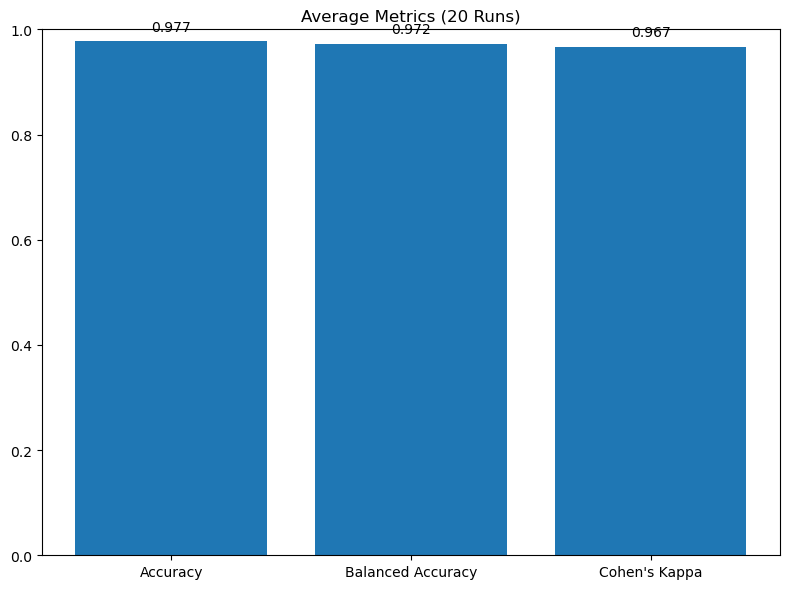

In [14]:
plt.figure(figsize=(8,6))

metrics_names = ["Accuracy", "Balanced Accuracy", "Cohen's Kappa"]
values = [mean_acc, mean_bal_acc, mean_kappa]

bars = plt.bar(metrics_names, values)
plt.ylim(0,1)
plt.title("Average Metrics (20 Runs)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02,
             f'{yval:.3f}', ha='center')

plt.tight_layout()
plt.savefig(f"{dd1}_mean_metrics_20runs.png", dpi=150)
plt.show()

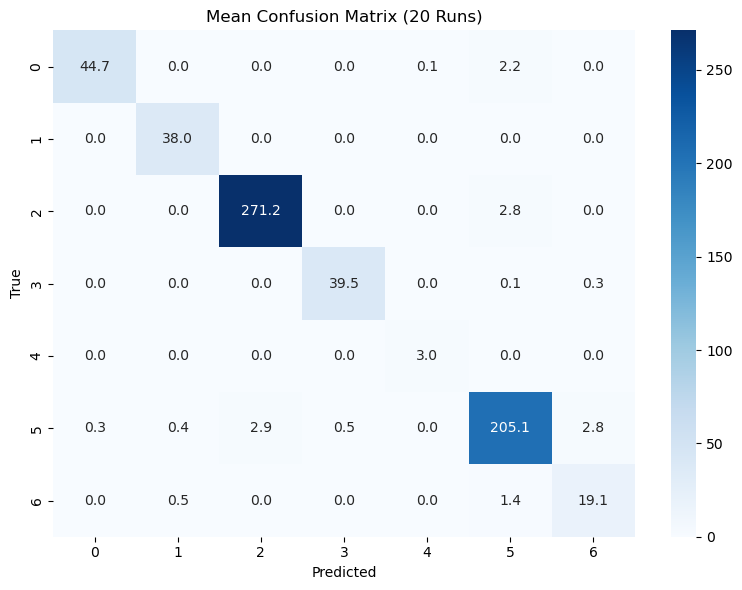

In [15]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(mean_cm, annot=True, fmt=".1f", cmap="Blues")
plt.title("Mean Confusion Matrix (20 Runs)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{dd1}_mean_confusion_matrix.png", dpi=150)
plt.show()

class_names = [
   a=> 'contact pot to be social',
   b>= 'rearing',
   c>= 'locomotion',
   d) => 'contact pot not to be social',
    e=>'contact pot social',
   f=> 'contact pot non social'
]

In [16]:

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------
# Estilo visual
# -----------------------------------------------------------
plt.rc('lines', linewidth=1.0, linestyle='--')
plt.rc('axes', linewidth=1.2, labelsize=22, titlesize=22)
plt.rc('xtick', labelsize=18, bottom=False)
plt.rc('ytick', labelsize=18, left=False)
plt.rc('legend', frameon=False, fontsize=18, loc='best')

# -----------------------------------------------------------
# Configuração inicial
# -----------------------------------------------------------
class_names = [
    '(a)',
    '(b)',
    '(c)',
    '(d)',
    '(e)',
    '(f)'
]
num_classes = len(class_names)
top_n = 10


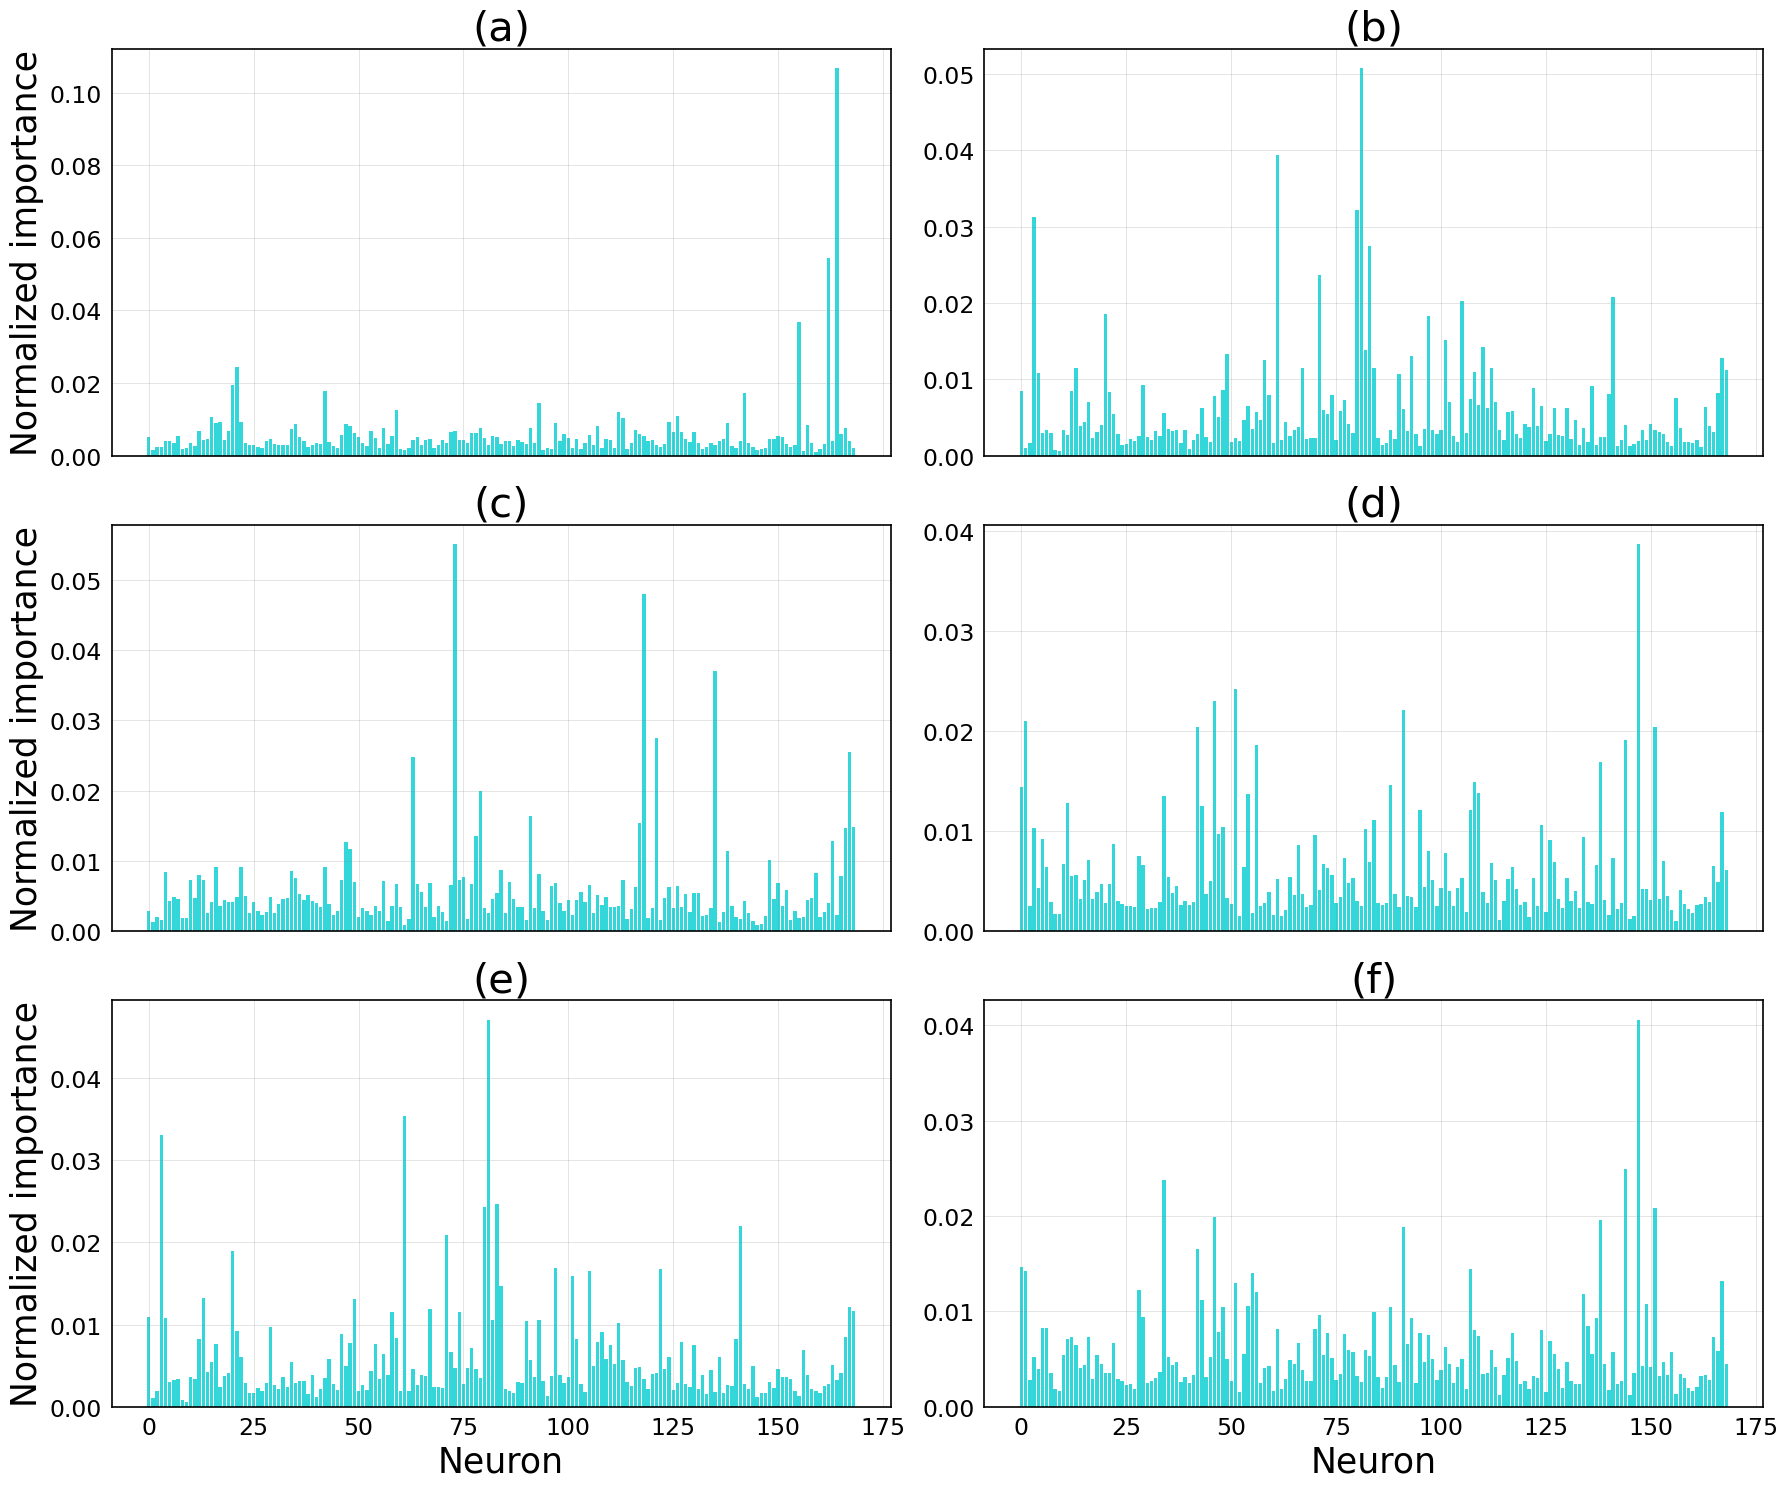

In [55]:
# ===============================================================
# 🔬 Neural Importance Analysis (Gradiente × Entrada)
# Média sobre 20 execuções
# ===============================================================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------
# Estilo visual
# -----------------------------------------------------------
plt.rc('lines', linewidth=1.0, linestyle='--')
plt.rc('axes', linewidth=1.2, labelsize=22, titlesize=22)
plt.rc('xtick', labelsize=18, bottom=False)
plt.rc('ytick', labelsize=18, left=False)
plt.rc('legend', frameon=False, fontsize=18, loc='best')

# -----------------------------------------------------------
# Configuração inicial
# -----------------------------------------------------------
class_names = [
    '(a)',
    '(b)',
    '(c)',
    '(d)',
    '(e)',
    '(f)'
]
num_classes = len(class_names)
top_n = 10

# ===============================================================
# 1️⃣ Subplot: importância média dos neurônios (barras)
# ===============================================================
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for classe_idx in range(num_classes):
    classe_desejada = class_names[classe_idx].capitalize()

    # Seleciona subconjunto da classe
    mask = y_windows == classe_idx
    X_subset = X_windows[mask][:min(50, np.sum(mask))]

    # ===============================================================
    # 🔥 MÉDIA DAS 20 RUNS
    # ===============================================================
    importances_runs = []

    for model in models_list:  # models_list contém os 20 modelos
        importances_model = []
        for X_sample in X_subset:
            X_input = tf.convert_to_tensor(X_sample[np.newaxis, ...], dtype=tf.float32)
            with tf.GradientTape() as tape:
                tape.watch(X_input)
                pred = model(X_input)
                loss = pred[0, classe_idx]
            grads = tape.gradient(loss, X_input)
            imp = tf.reduce_mean(tf.abs(grads * X_input), axis=1).numpy().flatten()
            importances_model.append(imp)
        # média por modelo
        if importances_model:
            importances_runs.append(np.mean(importances_model, axis=0))

    # média final sobre os 20 modelos
    if importances_runs:
        importance_class = np.mean(importances_runs, axis=0)
        importance_class /= importance_class.sum()  # normalização
    else:
        continue

    # Plotagem
    ax = axes[classe_idx]
    ax.bar(range(len(importance_class)), importance_class, color='darkturquoise', alpha=0.8)
    ax.set_title(f"{classe_desejada}", fontsize=30)

    # -------------------------------
    # Regras para eixo Y (somente 1ª coluna)
    # -------------------------------
    if classe_idx % 2 == 0:
        ax.set_ylabel("Normalized importance", fontsize=25)

    # -------------------------------
    # Regras para eixo X (somente última linha)
    # -------------------------------
    if classe_idx >= 4:
        ax.set_xlabel("Neuron", fontsize=25)
    else:
        ax.set_xticklabels([])

    ax.tick_params(axis='x', labelsize=17)
    ax.tick_params(axis='y', labelsize=17)
    ax.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.3)
fig.subplots_adjust(
    left=0.05,
    right=0.88,   # espaço reservado para colorbar
    top=0.95,
    bottom=0.05,
    hspace=0.5,
    wspace=0.5
)
plt.tight_layout()
fig.savefig(f"{dd1}_importance_neurons_gradxinput_mean20_b.png", dpi=200)
plt.show()

In [17]:
# 🔹 Calcular vmin/vmax globais com corte em quantis
# ===============================================================
all_z_values = []

for classe_idx in range(num_classes):
    mask = y_windows == classe_idx
    X_subset = X_windows[mask][:min(50, np.sum(mask))]
    if len(X_subset) == 0:
        continue

    X_input = tf.convert_to_tensor(X_subset[-1][np.newaxis, ...], dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_input)
        pred = model(X_input)
        loss = pred[0, classe_idx]

    grads = tape.gradient(loss, X_input)
    heatmap_data = np.abs(grads[0].numpy()) * X_input[0].numpy()

    mean_val = np.mean(heatmap_data)
    std_val = np.std(heatmap_data)
    if std_val == 0:
        std_val = 1e-8

    heatmap_data_z = (heatmap_data - mean_val) / std_val
    all_z_values.append(heatmap_data_z.flatten())

all_z_values = np.concatenate(all_z_values)
vmin, vmax = np.percentile(all_z_values, [2, 98])


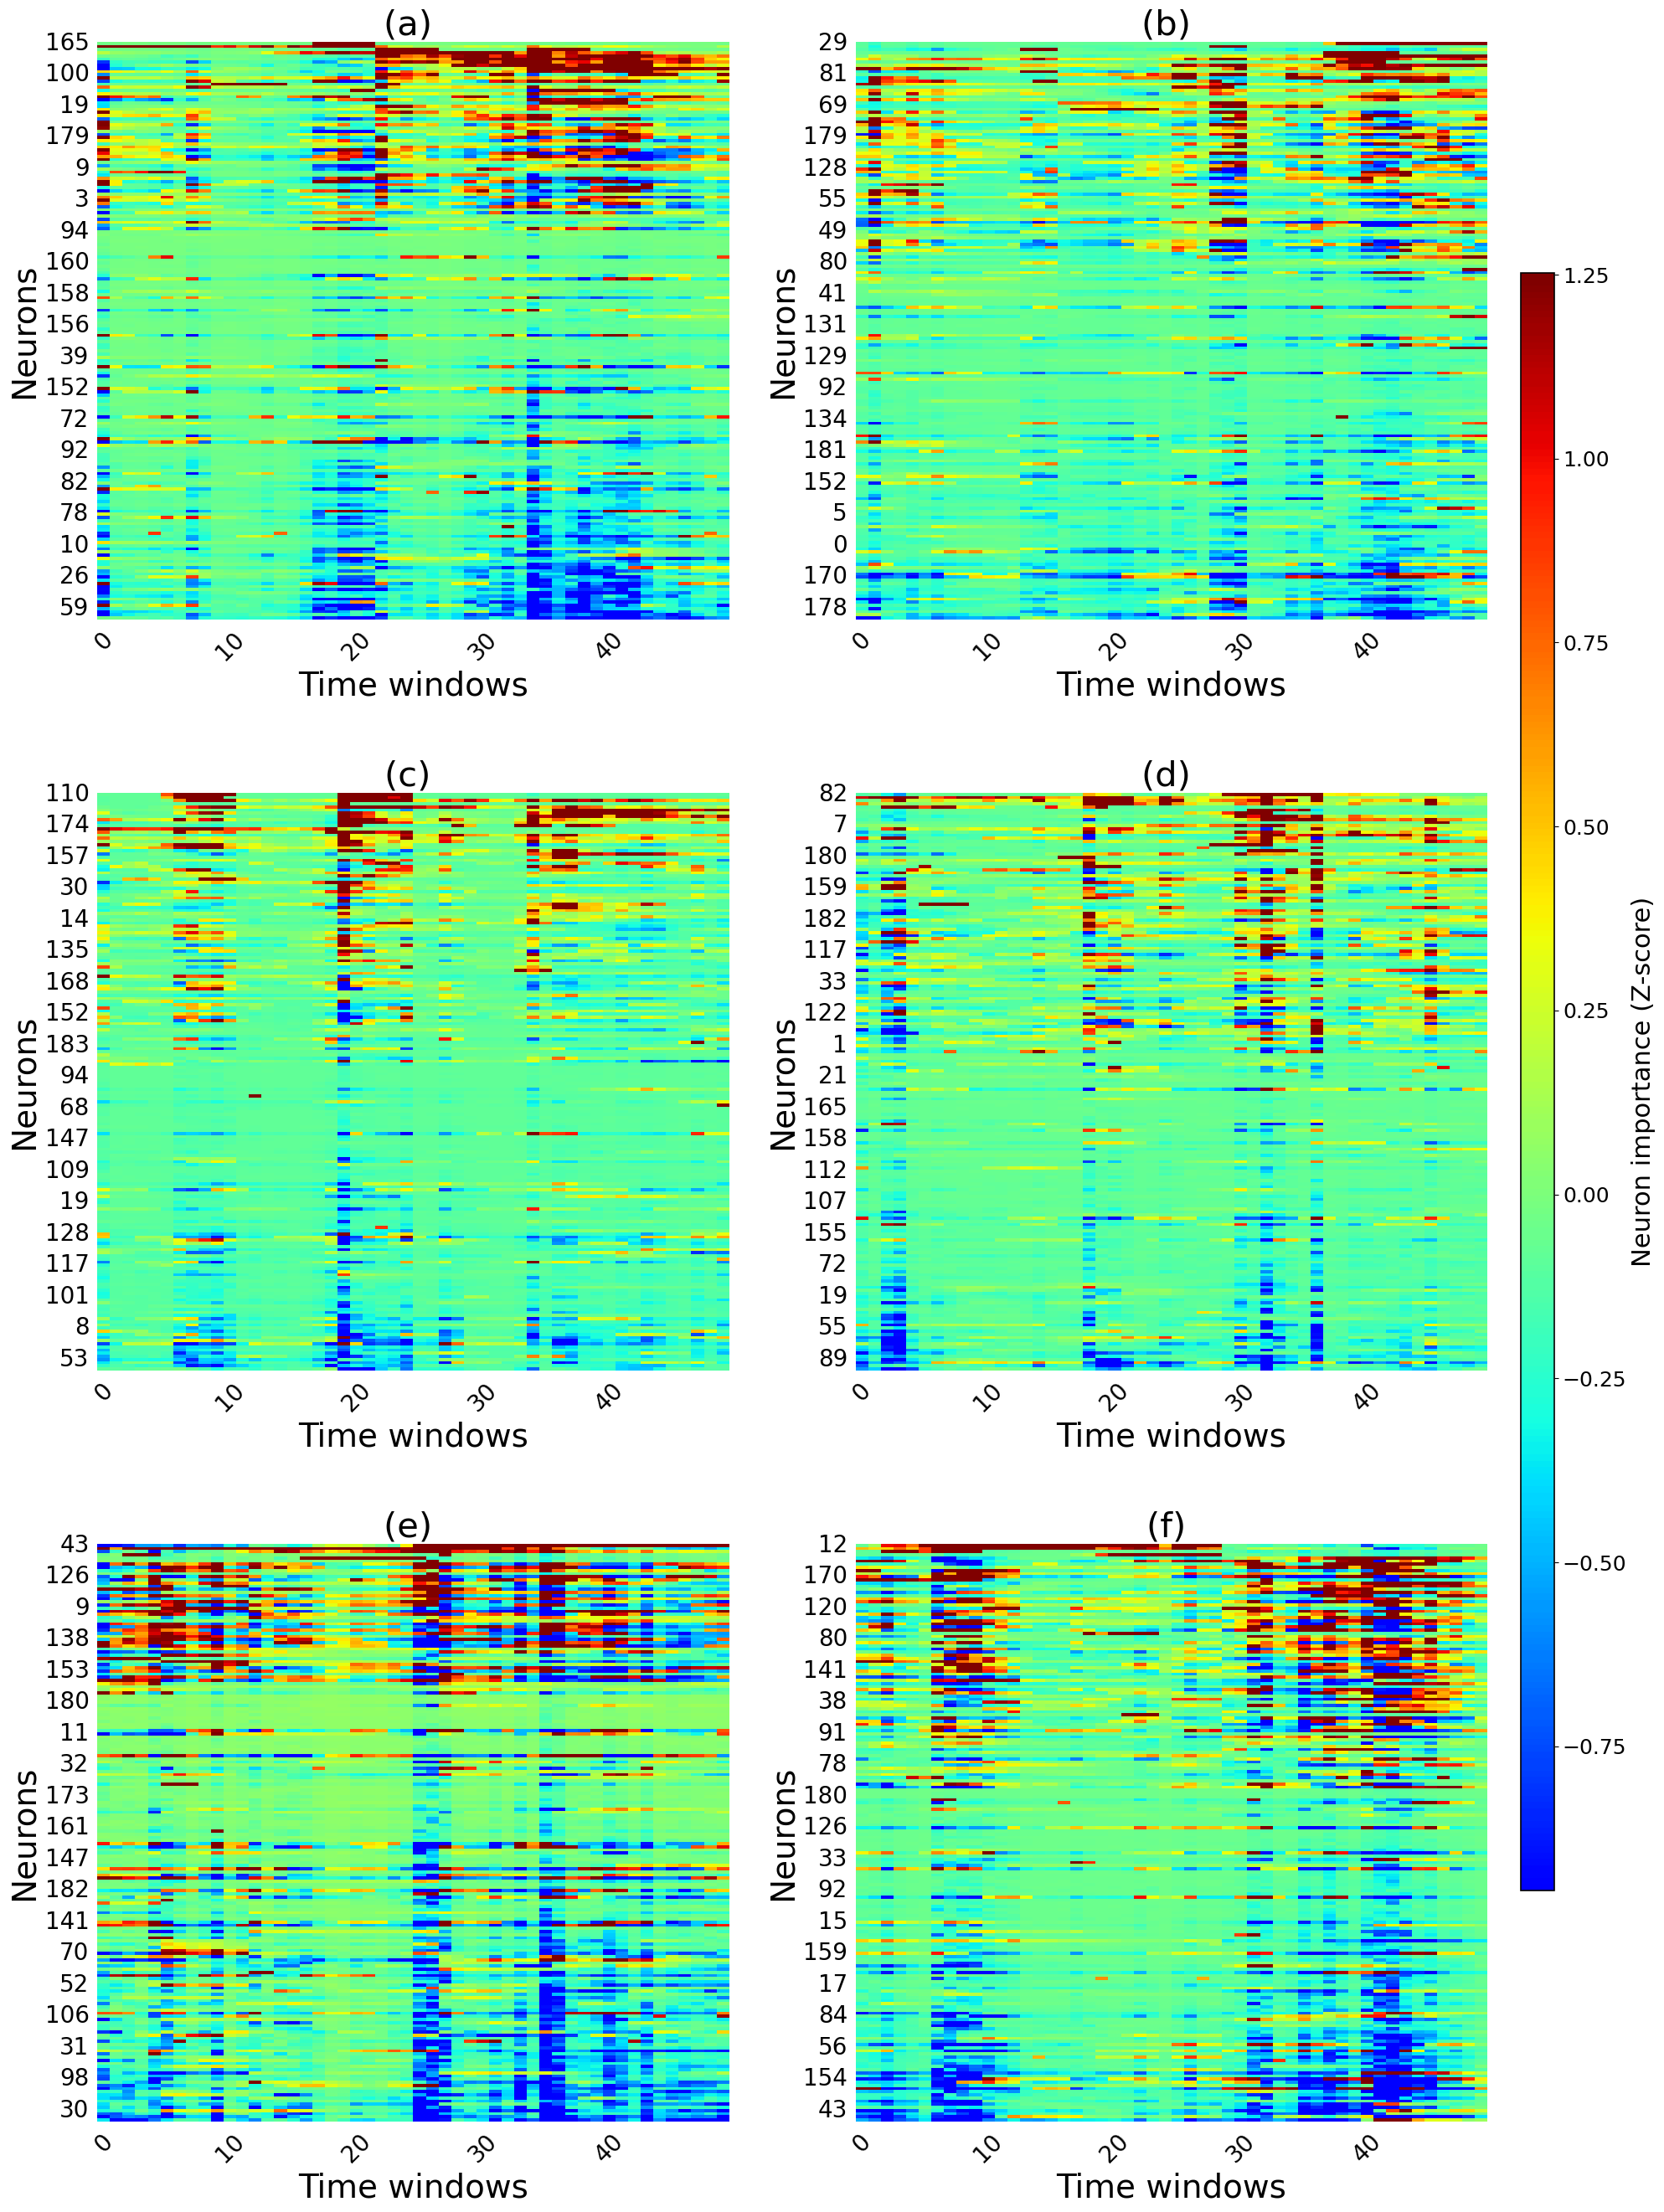

In [18]:
# ===============================================================
# 🔵 HEATMAP MÉDIO — TODOS OS NEURÔNIOS (20 RUNS)
# ===============================================================

height_per_neuron = 0.15
num_neurons = X_windows.shape[2]
fig_height = max(16, num_neurons * height_per_neuron)

fig, axes = plt.subplots(3, 2, figsize=(20, fig_height))
axes = axes.flatten()

mappable_for_cbar = None

for classe_idx in range(num_classes):

    classe_desejada = class_names[classe_idx].capitalize()
    mask = y_windows == classe_idx
    X_subset = X_windows[mask][:min(50, np.sum(mask))]
    
    if len(X_subset) == 0:
        continue

    # ===============================================================
    # 🔥 MÉDIA DAS 20 RUNS
    # ===============================================================
    heatmaps_runs = []

    for model in models_list:

        X_input = tf.convert_to_tensor(
            X_subset[-1][np.newaxis, ...],
            dtype=tf.float32
        )

        with tf.GradientTape() as tape:
            tape.watch(X_input)
            pred = model(X_input)
            loss = pred[0, classe_idx]

        grads = tape.gradient(loss, X_input)
        heatmap_data = np.abs(grads[0].numpy()) * X_input[0].numpy()
        heatmaps_runs.append(heatmap_data)

    # Média entre as 20 execuções
    heatmap_mean = np.mean(heatmaps_runs, axis=0)

    # ===============================================================
    # Z-score
    # ===============================================================
    mean_val = np.mean(heatmap_mean)
    std_val = np.std(heatmap_mean)
    std_val = std_val if std_val != 0 else 1e-8

    heatmap_data_z = (heatmap_mean - mean_val) / std_val

    # ===============================================================
    # Ordenação por importância média
    # ===============================================================
    importance_sum = np.sum(heatmap_data_z, axis=0)
    neuron_order = np.argsort(importance_sum)[::-1]

    heatmap_sorted = heatmap_data_z[:, neuron_order].T

    ax = axes[classe_idx]

    hm = sns.heatmap(
        heatmap_sorted,
        ax=ax,
        cmap='jet',
        center=0,
        vmin=vmin,
        vmax=vmax,
        cbar=False
    )

    if mappable_for_cbar is None:
        mappable_for_cbar = hm.get_children()[0]

    # 🔹 Mostrar todos os neurônios
    step_y = 10
    yticks = np.arange(0, len(neuron_order), step_y)

    ax.set_yticks(yticks + 0.5)
    ax.set_yticklabels(neuron_order[yticks], fontsize=20)
    
    # 🔹 Xticks (time windows)
    step_x = 10
    xticks = np.arange(0, heatmap_sorted.shape[1], step_x)
    ax.set_xticks(xticks + 0.5)
    ax.set_xticklabels(xticks, fontsize=20, rotation=45)
    ax.set_xlabel("Time windows", fontsize=28)
    ax.set_ylabel("Neurons", fontsize=28)
    ax.set_title(f"{classe_desejada} ", fontsize=30)

  #  ax.axvline(frame_zero, color='white', linestyle='--', linewidth=1)
    ax.grid(False)

fig.subplots_adjust(
    left=0.05,
    right=0.88,   # espaço reservado para colorbar
    top=0.95,
    bottom=0.05,
    hspace=0.3,
    wspace=0.2
)

# Colorbar fora dos subplots
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(
    mappable_for_cbar,
    cax=cbar_ax,
    label='Neuron importance (Z-score)'
)
fig.savefig(
    f"{dd1}_ALL_NEURONS_MEAN_20RUNS_b.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

Classe: (a) → 41 neurônios (Z > 1.96)
Classe: (b) → 34 neurônios (Z > 1.96)
Classe: (c) → 41 neurônios (Z > 1.96)
Classe: (d) → 54 neurônios (Z > 1.96)
Classe: (e) → 66 neurônios (Z > 1.96)
Classe: (f) → 70 neurônios (Z > 1.96)


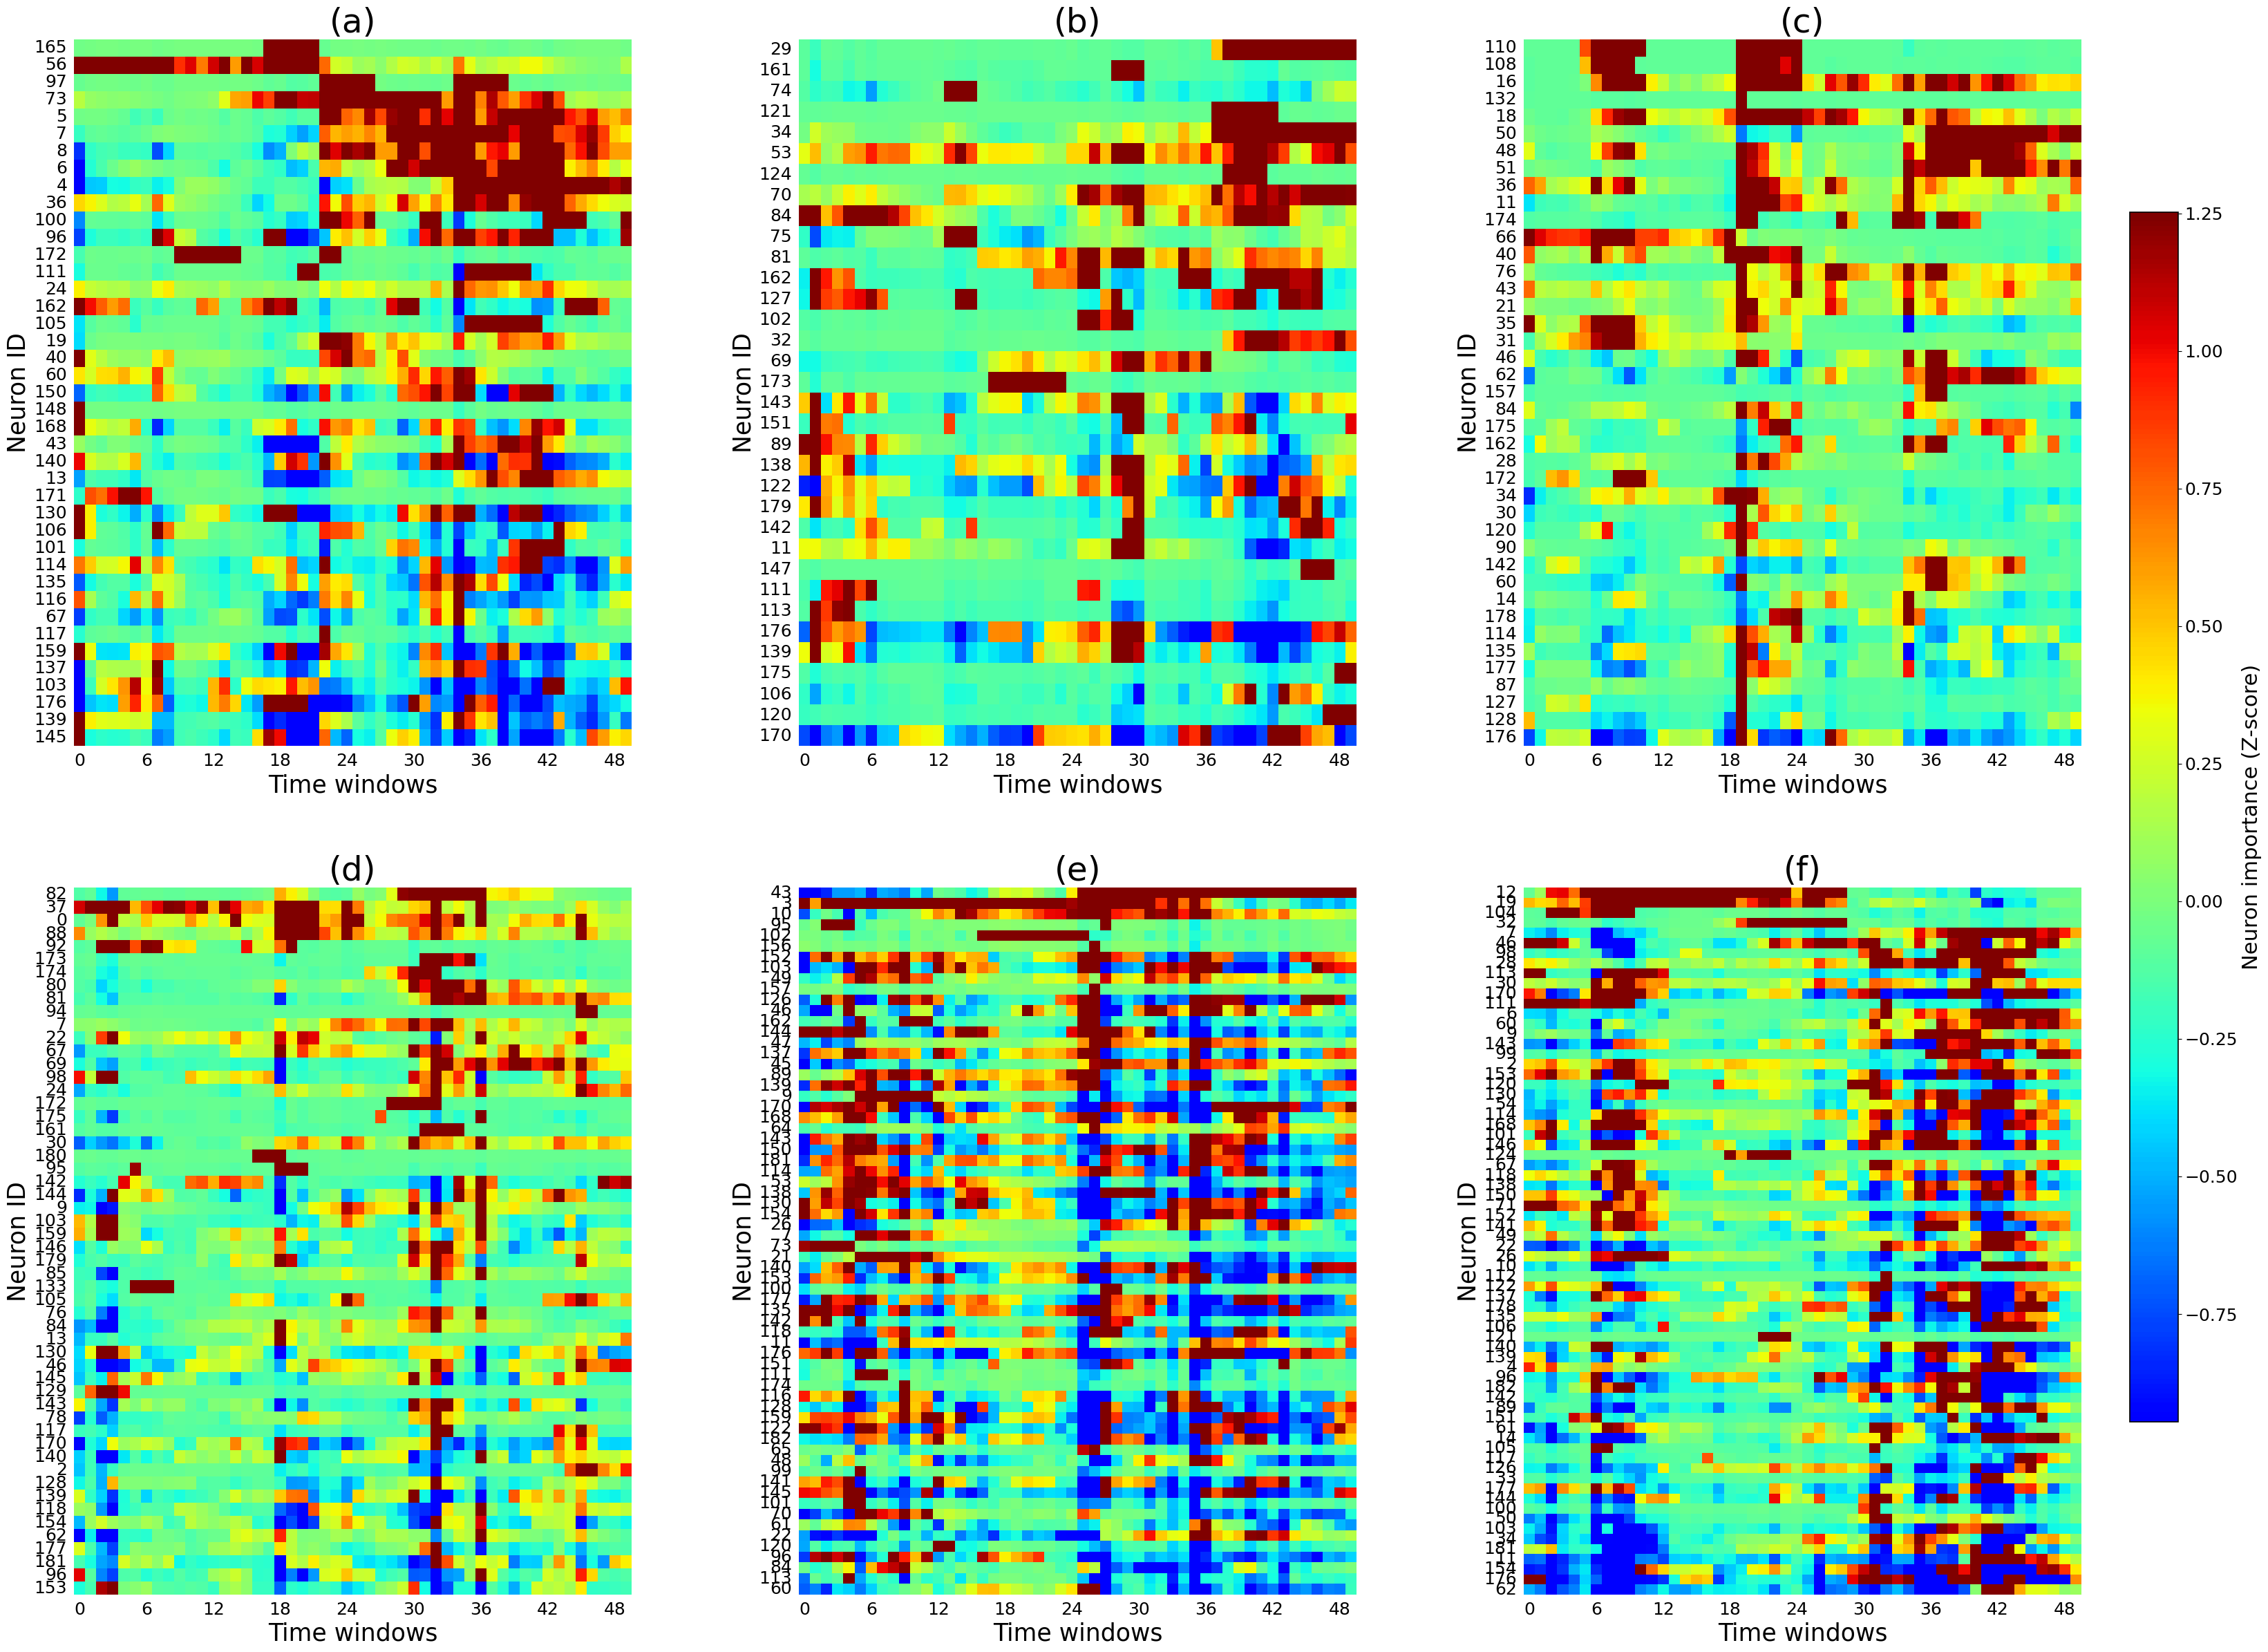

In [19]:
# ===============================================================
# 🔴 HEATMAP MÉDIO — NEURÔNIOS COM Z > 1.96
# ===============================================================

height_per_neuron = 0.18
fig, axes = plt.subplots(2, 3, figsize=(35, 25))
axes = axes.flatten()

mappable_for_cbar = None
# 🔥 ADICIONE AQUI
neurons_per_class = {}
for classe_idx in range(num_classes):

    classe_desejada = class_names[classe_idx].capitalize()
    mask = y_windows == classe_idx
    X_subset = X_windows[mask][:min(50, np.sum(mask))]

    if len(X_subset) == 0:
        continue

    # ===============================================================
    # 🔥 MÉDIA DAS 20 RUNS
    # ===============================================================
    heatmaps_runs = []

    for model in models_list:  # models_list contém os 20 modelos

        X_input = tf.convert_to_tensor(
            X_subset[-1][np.newaxis, ...],
            dtype=tf.float32
        )

        with tf.GradientTape() as tape:
            tape.watch(X_input)
            pred = model(X_input)
            loss = pred[0, classe_idx]

        grads = tape.gradient(loss, X_input)
        heatmap_data = np.abs(grads[0].numpy()) * X_input[0].numpy()
        heatmaps_runs.append(heatmap_data)

    # Média entre as 20 execuções
    heatmap_mean = np.mean(heatmaps_runs, axis=0)

    # ===============================================================
    # Z-score
    # ===============================================================
    mean_val = np.mean(heatmap_mean)
    std_val = np.std(heatmap_mean)
    std_val = std_val if std_val != 0 else 1e-8
    heatmap_data_z = (heatmap_mean - mean_val) / std_val

    # ===============================================================
    # 🔥 FILTRO Z > 1.96
    # ===============================================================
    significant_mask = np.any(heatmap_data_z > 1.96, axis=0)
    significant_neurons = np.where(significant_mask)[0]
    
    # 🔥 ADICIONE AQUI
    n_neurons = len(significant_neurons)
    neurons_per_class[classe_desejada] = n_neurons
    print(f"Classe: {classe_desejada} → {n_neurons} neurônios (Z > 1.96)")
    
    if n_neurons == 0:
        continue

    # ===============================================================
    # Ordenação por importância
    # ===============================================================
    importance_sum = np.sum(heatmap_data_z, axis=0)
    neuron_order = np.argsort(importance_sum)[::-1]
    neuron_order_filtered = [n for n in neuron_order if n in significant_neurons]

    heatmap_sorted = heatmap_data_z[:, neuron_order_filtered].T

    ax = axes[classe_idx]

    hm = sns.heatmap(
        heatmap_sorted,
        ax=ax,
        cmap='jet',
        center=0,
        vmin=vmin,
        vmax=vmax,
        cbar=False
    )

    if mappable_for_cbar is None:
        mappable_for_cbar = hm.get_children()[0]

    # ==========================
    # 🔹 EIXO Y — Neuron ID
    # ==========================
    step_y = 1
    yticks = np.arange(0, len(neuron_order_filtered), step_y)
    ax.set_yticks(yticks + 0.5)
    #ax.set_yticklabels(np.array(neuron_order_filtered)[yticks], fontsize=14)
    ax.set_yticklabels(np.array(neuron_order_filtered)[yticks], fontsize=18, rotation=0)

    # ==========================
    # 🔹 EIXO X — JANELAS
    # ==========================
    num_windows = heatmap_sorted.shape[1]
    step_x = max(1, num_windows // 8)
    xticks = np.arange(0, num_windows, step_x)
    ax.set_xticks(xticks + 0.5)
    ax.set_xticklabels(xticks, fontsize=18)

    # Linha vertical no frame_zero
   # ax.axvline(frame_zero, color='white', linestyle='--', linewidth=1.5)

    # ==========================
    # Rótulos
    # ==========================
    ax.set_xlabel("Time windows", fontsize=25)
    ax.set_ylabel("Neuron ID", fontsize=25)
    ax.set_title(f"{classe_desejada}", fontsize=35)
    ax.grid(False)

# ==========================
# Layout
# ==========================
fig.subplots_adjust(
    left=0.05,
    right=0.88,   # espaço reservado para colorbar
    top=0.95,
    bottom=0.05,
    hspace=0.2,
    wspace=0.3
)

# Colorbar fora dos subplots
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(
    mappable_for_cbar,
    cax=cbar_ax,
    label='Neuron importance (Z-score)'
)
fig.savefig(
    f"{dd1}_SIGNIFICANT_NEURONS_WINDOWS_MEAN_20RUNS_b.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()
with open(f"{dd1}_neurons_per_class.txt", "w") as f:
    for classe, n in neurons_per_class.items():
        f.write(f"{classe}: {n} neurônios (Z > 1.96)\n")

# --------------------------------------- end loop------------------------------------------------------------------------------------